# EMTA andmete analüüs

## Me töötame pangas ja ül on teha ülevaade kuidas eesti majandusel läheb.


### Ettevalmistused

In [51]:
from typing import Callable
import pandas as pd
import duckdb

import matplotlib.pyplot as plt
import seaborn as sns

### Andmetega tutvumine

In [8]:
data_raw_this_year = pd.read_csv("tasutud_maksud_kaesolev_aasta.csv", nrows=5)
#data_raw_this_year.T -> transpose, et veerud saaksid readeks ja read veergudeks

data_raw_this_year


,Andmete seis,Registrikood,Nimi,Liik,Maakond,Tegevusala,Aasta,Riiklikud maksud I kv,Riiklikud maksud II kv,Riiklikud maksud III kv,...,Tööjõumaksud III kv,Tööjõumaksud IV kv,Käive I kv,Käive II kv,Käive III kv,Käive IV kv,Töötajate arv I kv,Töötajate arv II kv,Töötajate arv III kv,Töötajate arv IV kv
0,10.04.2026,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2025,1723565,2038192.0,2141341.0,...,1213643.0,1131417.0,34309154,30413704.0,23282177.0,21724706.0,254.0,243.0,244.0,240.0
1,10.04.2026,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2026,1561762,NaN,NaN,...,NaN,NaN,19993085,NaN,NaN,NaN,236.0,NaN,NaN,NaN
2,10.04.2026,10000024,"EESTI RAAMAT, OÜ",Äriühing,Harju ( Tallinn ),INFO JA SIDE,2025,40888,41980.0,38723.0,...,38979.0,36127.0,236677,235518.0,206299.0,280010.0,11.0,11.0,10.0,10.0
3,10.04.2026,10000024,"EESTI RAAMAT, OÜ",Äriühing,Harju ( Tallinn ),INFO JA SIDE,2026,48644,NaN,NaN,...,NaN,NaN,299247,NaN,NaN,NaN,11.0,NaN,NaN,NaN
4,10.04.2026,10000062,ALDO KOPPEL,FIE,Ida-Viru ( Lüganuse vald ),"PÕLLUMAJANDUS, METSAMAJANDUS JA KALAPÜÜK",2025,313,342.0,635.0,...,0.0,NaN,1941,2925.0,9273.0,906.0,NaN,NaN,NaN,NaN


In [9]:
duckdb.sql("""
           FROM 'tasutud_maksud_varasemad_aastad.csv'
           lIMIT 5
""").df()

,Andmete seis,Registrikood,Nimi,Liik,Maakond,Tegevusala,Aasta,Riiklikud maksud I kv,Riiklikud maksud II kv,Riiklikud maksud III kv,...,Tööjõumaksud III kv,Tööjõumaksud IV kv,Käive I kv,Käive II kv,Käive III kv,Käive IV kv,Töötajate arv I kv,Töötajate arv II kv,Töötajate arv III kv,Töötajate arv IV kv
0,2026-04-10,01834351,"LOMBI-13, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),NaN,2022,<NA>,288,<NA>,...,<NA>,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,2026-04-10,01834351,"LOMBI-13, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),NaN,2023,<NA>,288,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,2026-04-10,01834351,"LOMBI-13, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),NaN,2024,288,52,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,2026-04-10,01834575,"KUNDERI 24, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),NaN,2024,<NA>,<NA>,268,...,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,2026-04-10,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2022,1300554,1645555,1185273,...,923188,950362,22930261,31976194,26140614,31599227,214,228,231,232


### Tahaks need kaks tabelit kokku panna

In [14]:
# kontrollime, kas tulpade nimed on samad, et saaksime neid andmeid ühte tabelisse ühendada

data_raw_new = pd.read_csv("tasutud_maksud_kaesolev_aasta.csv", nrows=5)
data_raw_old = pd.read_csv("tasutud_maksud_varasemad_aastad.csv", nrows=5)
data_raw_new.columns == data_raw_old.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [17]:
data_raw= duckdb.sql("""
           FROM 'tasutud_maksud_kaesolev_aasta.csv'
           UNION ALL
           FROM 'tasutud_maksud_varasemad_aastad.csv'
""").df()
data_raw

,Andmete seis,Registrikood,Nimi,Liik,Maakond,Tegevusala,Aasta,Riiklikud maksud I kv,Riiklikud maksud II kv,Riiklikud maksud III kv,...,Tööjõumaksud III kv,Tööjõumaksud IV kv,Käive I kv,Käive II kv,Käive III kv,Käive IV kv,Töötajate arv I kv,Töötajate arv II kv,Töötajate arv III kv,Töötajate arv IV kv
0,2026-04-10,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2025,1723565,2038192,2141341,...,1213643,1131417,34309154,30413704,23282177,21724706,254,243,244,240
1,2026-04-10,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2026,1561762,<NA>,<NA>,...,<NA>,<NA>,19993085,<NA>,<NA>,<NA>,236,<NA>,<NA>,<NA>
2,2026-04-10,10000024,"EESTI RAAMAT, OÜ",Äriühing,Harju ( Tallinn ),INFO JA SIDE,2025,40888,41980,38723,...,38979,36127,236677,235518,206299,280010,11,11,10,10
3,2026-04-10,10000024,"EESTI RAAMAT, OÜ",Äriühing,Harju ( Tallinn ),INFO JA SIDE,2026,48644,<NA>,<NA>,...,<NA>,<NA>,299247,<NA>,<NA>,<NA>,11,<NA>,<NA>,<NA>
4,2026-04-10,10000062,ALDO KOPPEL,FIE,Ida-Viru ( Lüganuse vald ),"PÕLLUMAJANDUS, METSAMAJANDUS JA KALAPÜÜK",2025,313,342,635,...,0,<NA>,1941,2925,9273,906,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1070347,2026-04-10,OO000012,HANDELSBOLAGET KORSVÄGEN FÖRVALTING,Mitteresident,NaN,NaN,2024,2,13,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1070348,2026-04-10,OO000015,TRUST FINANCING AB,Mitteresident,NaN,NaN,2024,<NA>,83,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1070349,2026-04-10,QQ000003,RAUMASTER OY,Mitteresident,NaN,HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2022,24114,18514,21953,...,21802,22937,26908,26851,86902,23302,3,3,3,3
1070350,2026-04-10,QQ000003,RAUMASTER OY,Mitteresident,NaN,HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2023,23447,20816,23767,...,24487,23491,18309,19522,7596,47353,3,3,3,4


### Teen tabeli kasulikuks - maakonnad lahku, iga kvartal võiks saada oma rea (pivot operatsioon), andmete seis kaotame ära

In [19]:
data_unpivot =duckdb.sql("""
WITH base AS (
    SELECT
        "Andmete seis",
        "Registrikood",
        "Nimi",
        "Liik",
        "Maakond",
        "Tegevusala",
        "Aasta",
        "Riiklikud maksud I kv" AS riiklikud_maksud_1,
        "Riiklikud maksud II kv" AS riiklikud_maksud_2,
        "Riiklikud maksud III kv" AS riiklikud_maksud_3,
        "Riiklikud maksud IV kv" AS riiklikud_maksud_4,
        "Tööjõumaksud I kv" AS toojou_maksud_1,
        "Tööjõumaksud II kv" AS toojou_maksud_2,
        "Tööjõumaksud III kv" AS toojou_maksud_3,
        "Tööjõumaksud IV kv" AS toojou_maksud_4,
        "Käive I kv" AS kaive_1,
        "Käive II kv" AS kaive_2,
        "Käive III kv" AS kaive_3,
        "Käive IV kv" AS kaive_4,
        "Töötajate arv I kv" AS tootajad_1,
        "Töötajate arv II kv" AS tootajad_2,
        "Töötajate arv III kv" AS tootajad_3,
        "Töötajate arv IV kv" AS tootajad_4
    FROM data_raw
)
UNPIVOT base
ON
    (riiklikud_maksud_1, toojou_maksud_1, kaive_1, tootajad_1),
    (riiklikud_maksud_2, toojou_maksud_2, kaive_2, tootajad_2),
    (riiklikud_maksud_3, toojou_maksud_3, kaive_3, tootajad_3),
    (riiklikud_maksud_4, toojou_maksud_4, kaive_4, tootajad_4)
INTO
    NAME kvartal
    VALUE riiklikud_maksud, toojoumaksud, kaive, tootajate_arv;
""").df()
data_unpivot[:3] # näitab ainult viimast kolme rida, et ei peaks kogu tabelit näitama.

,Andmete seis,Registrikood,Nimi,Liik,Maakond,Tegevusala,Aasta,kvartal,riiklikud_maksud,toojoumaksud,kaive,tootajate_arv
0,2026-04-10,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2025,riiklikud_maksud_1_toojou_maksud_1_kaive_1_too...,1723565,1259900,34309154,254
1,2026-04-10,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2025,riiklikud_maksud_2_toojou_maksud_2_kaive_2_too...,2038192,1229742,30413704,243
2,2026-04-10,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2025,riiklikud_maksud_3_toojou_maksud_3_kaive_3_too...,2141341,1213643,23282177,244


In [29]:
duckdb.sql("""
SELECT DiSTINCT maakond
FROM data_unpivot
""")

┌────────────────────────────────┐
│            Maakond             │
│            varchar             │
├────────────────────────────────┤
│ Tartu ( Tartu linn )           │
│ Tartu ( Tartu vald )           │
│ Tartu ( Luunja vald )          │
│ Viljandi ( Põhja-Sakala vald ) │
│ Lääne-Viru ( Rakvere vald )    │
│ Rapla ( Rapla vald )           │
│ Jõgeva ( Jõgeva vald )         │
│ Jõgeva ( Mustvee vald )        │
│ Lääne ( Vormsi vald )          │
│ Harju ( Tallinn )              │
│         ·                      │
│         ·                      │
│         ·                      │
│ Harju ( Maardu linn )          │
│ Rapla ( Kohila vald )          │
│ Harju ( Saue vald )            │
│ Harju ( Kose vald )            │
│ Järva ( Türi vald )            │
│ Pärnu ( Häädemeeste vald )     │
│ Pärnu ( Põhja-Pärnumaa vald )  │
│ Harju ( Loksa linn )           │
│ Valga ( Tõrva vald )           │
│ Saare ( Ruhnu vald )           │
└────────────────────────────────┘
        79 rows (20 

In [ ]:
def eralda_maakond(maakond: str) -> str:
    return maakond.split(" ( ")[0]

def eralda_kov(maakond: str) -> str:
    return maakond.split(" ( ")[1][:-2]
    return maakond.split(" ( ")[1].replace(")","") # sama mis eelmine rida, aga veidi loetavam

def puhasta_kvartal(kvartal: str) -> int:
    return int(kvartal[-1])

def peamine_tegevusala(tegevusalad: str) -> str:
    return tegevusalad.split(";")[0]

# alakriipsuga funktsioonid on mõeldud kasutamiseks ainult selle faili sees, neid ei tohiks kasutada teistes failides, 
# kuna need on spetsiifilised just selle faili jaoks ja võivad teistes kontekstides põhjustada segadust või konflikte.
def _register_duckdb_function(duckdb_function_name: str, function: Callable) -> None: # annotation pole vajalik kirja panna, aga aitab mõista, mida funktsioon teeb
    try:
        duckdb.remove_function(duckdb_function_name)
    except:
        pass
    duckdb.create_function(duckdb_function_name, function)

_register_duckdb_function(duckdb_function_name="puhasta_kvartal", function=puhasta_kvartal)
_register_duckdb_function(duckdb_function_name="eralda_maakond", function=eralda_maakond)
_register_duckdb_function(duckdb_function_name="eralda_kov", function=eralda_kov)
_register_duckdb_function(duckdb_function_name="peamine_tegevusala", function=peamine_tegevusala)

"""
try:
    duckdb.remove_function("puhasta_kvartal")
except:
    pass
duckdb.create_function("puhasta_kvartal", puhasta_kvartal)

try:
    duckdb.remove_function("eralda_maakond")
except:
    pass
duckdb.create_function("eralda_maakond", eralda_maakond)
try:
    duckdb.remove_function("eralda_kov")
except:
    pass
duckdb.create_function("eralda_kov", eralda_kov)"""


'\ntry:\n    duckdb.remove_function("puhasta_kvartal")\nexcept:\n    pass\nduckdb.create_function("puhasta_kvartal", puhasta_kvartal)\n\ntry:\n    duckdb.remove_function("eralda_maakond")\nexcept:\n    pass\nduckdb.create_function("eralda_maakond", eralda_maakond)\ntry:\n    duckdb.remove_function("eralda_kov")\nexcept:\n    pass\nduckdb.create_function("eralda_kov", eralda_kov)'

In [23]:
eralda_maakond("Lääne-Viru (Viru-Nigula vald)")

'Lääne-Viru'

In [36]:
eralda_kov("Pärnu ( Põhja-Pärnumaa vald )")

'Põhja-Pärnumaa vald'

### Kasutan sql pythoni sees duckdb abiga

In [ ]:
data = duckdb.sql("""
    SELECT
        Registrikood AS registrikood,
        Nimi AS nimi,
        Liik AS liik,
        eralda_maakond(maakond) AS maakond,
        eralda_kov(maakond) AS kov,
        peamine_tegevusala(tegevusala) AS tegevusala,
        Aasta AS aasta,
        puhasta_kvartal(kvartal) AS kvartal,
        riiklikud_maksud,
        toojoumaksud,
        kaive,
        tootajate_arv 
    FROM data_unpivot
""").df()

data # näitab kogu tabelit, aga kuna see on väga suur, siis näitab ainult esimest ja viimast 5 rida. 
#Kui tahame näha rohkem ridu, siis saame kasutada data.head(10) või data.tail(10) jne.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,registrikood,nimi,liik,maakond,kov,tegevusala,aasta,kvartal,riiklikud_maksud,toojoumaksud,kaive,tootajate_arv
0,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,1,1723565,1259900,34309154,254
1,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,2,2038192,1229742,30413704,243
2,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,3,2141341,1213643,23282177,244
3,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,4,1844403,1131417,21724706,240
4,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2026,1,1561762,1088007,19993085,236
...,...,...,...,...,...,...,...,...,...,...,...,...
943929,QQ000003,RAUMASTER OY,Mitteresident,NaN,NaN,HULGI- JA JAEKAUBANDUS,2023,4,22804,23491,47353,4
943930,QQ000003,RAUMASTER OY,Mitteresident,NaN,NaN,HULGI- JA JAEKAUBANDUS,2024,1,31928,33059,99940,4
943931,QQ000003,RAUMASTER OY,Mitteresident,NaN,NaN,HULGI- JA JAEKAUBANDUS,2024,2,25677,26511,5551,4
943932,QQ000003,RAUMASTER OY,Mitteresident,NaN,NaN,HULGI- JA JAEKAUBANDUS,2024,3,27572,28496,0,4


In [112]:
duckdb.sql("""
           select distinct tegevusala
           from data
           """)

┌────────────────────────────────────────────────────────────────────┐
│                             tegevusala                             │
│                              varchar                               │
├────────────────────────────────────────────────────────────────────┤
│ TÖÖTLEV TÖÖSTUS                                                    │
│ INFO JA SIDE                                                       │
│ KINNISVARAALANE TEGEVUS                                            │
│ VEEVARUSTUS                                                        │
│ MAJUTUS JA TOITLUSTUS                                              │
│ FINANTS- JA KINDLUSTUSTEGEVUS                                      │
│ ELEKTRIENERGIA, GAASI, AURU JA KONDITSIONEERITUD ÕHUGA VARUSTAMINE │
│ NULL                                                               │
│ AVALIK HALDUS JA RIIGIKAITSE                                       │
│ HULGI- JA JAEKAUBANDUS                                             │
│ MUUD

### See on funktsiooni defineerimise ja loopi näide, et näha, kuidas funktsioonid töötavad

In [66]:
def kirjutasona(tahanloppu: str, mitukorda: int):
    for i in range(mitukorda):
        print(f"tereeeeeee {tahanloppu}")

In [67]:
kirjutasona(".", 3)
kirjutasona("!", 1)
kirjutasona("?", 2)
kirjutasona("...", 1)

tereeeeeee .
tereeeeeee .
tereeeeeee .
tereeeeeee !
tereeeeeee ?
tereeeeeee ?
tereeeeeee ...


### Avastuslik andmeanalüüs (*Exploratory analysis*)

In [72]:
duckdb.sql("""
    SUMMARIZE data""")

┌──────────────────┬─────────────┬──────────────────────────────────────────────────────────────┬────────────────────┬───────────────┬────────────────────┬────────────────────┬─────────┬─────────┬─────────┬────────┬─────────────────┐
│   column_name    │ column_type │                             min                              │        max         │ approx_unique │        avg         │        std         │   q25   │   q50   │   q75   │ count  │ null_percentage │
│     varchar      │   varchar   │                           varchar                            │      varchar       │     int64     │      varchar       │      varchar       │ varchar │ varchar │ varchar │ int64  │  decimal(9,2)   │
├──────────────────┼─────────────┼──────────────────────────────────────────────────────────────┼────────────────────┼───────────────┼────────────────────┼────────────────────┼─────────┼─────────┼─────────┼────────┼─────────────────┤
│ registrikood     │ VARCHAR     │ 10000018                     

In [93]:
negatiivne_kaive = duckdb.sql("""
    SELECT 
        nimi, 
        maakond, 
        tegevusala, 
        aasta, 
        kvartal, 
        kaive, 
        tootajate_arv
    FROM data
    WHERE kaive < 0
    ORDER BY kaive ASC
    LIMIT 5
""").df()

print("Suurimad negatiivsed käibed:")
display(negatiivne_kaive)

Suurimad negatiivsed käibed:


,nimi,maakond,tegevusala,aasta,kvartal,kaive,tootajate_arv
0,SUNLY AS,Harju,"KUTSE-, TEADUS- JA TEHNIKAALANE TEGEVUS",2023,1,-8624365,31
1,INDRA SISTEMAS S.A. EESTI FILIAAL,Harju,INFO JA SIDE,2025,3,-4387932,1
2,AS RAUDTEE VARAD,Harju,VEONDUS JA LAONDUS,2024,1,-2673325,28
3,INDRA SISTEMAS S.A. EESTI FILIAAL,Harju,INFO JA SIDE,2026,1,-1053491,1
4,DEROSSI MARINE OÜ,Harju,TÖÖTLEV TÖÖSTUS,2025,4,-989605,5


### Kui palju on maakonniti ettevõtteid ja nende keskmine käive. Selle aasta esimene kvartal

In [100]:
duckdb.sql("""
SELECT  
    maakond, 
    count(DISTINCT registrikood) AS ettevotete_arv,
    round(avg(kaive), 2):: int AS keskmine_kvartaalne_kaive, 
    round(avg(kaive)/3):: int AS keskmine_kuuline_kaive
FROM data
WHERE aasta = 2026 and kvartal = 1
GROUP BY maakond
""").df()

#:: int tähendab, et tulemus ümardatakse täisarvuks

,maakond,ettevotete_arv,keskmine_kvartaalne_kaive,keskmine_kuuline_kaive
0,Ida-Viru,2423,232863,77621
1,Rapla,1428,178514,59505
2,Pärnu,3536,217507,72502
3,Tartu,6616,361536,120512
4,Võru,1259,216443,72148
5,Lääne,808,161612,53871
6,NaN,141,762548,254183
7,Lääne-Viru,2095,317690,105897
8,Viljandi,1723,266402,88801
9,Saare,1358,187316,62439


### Vaatame töötjate arvu tegevusalade kaupa

<Axes: xlabel='tootajate_arv', ylabel='tegevusala'>

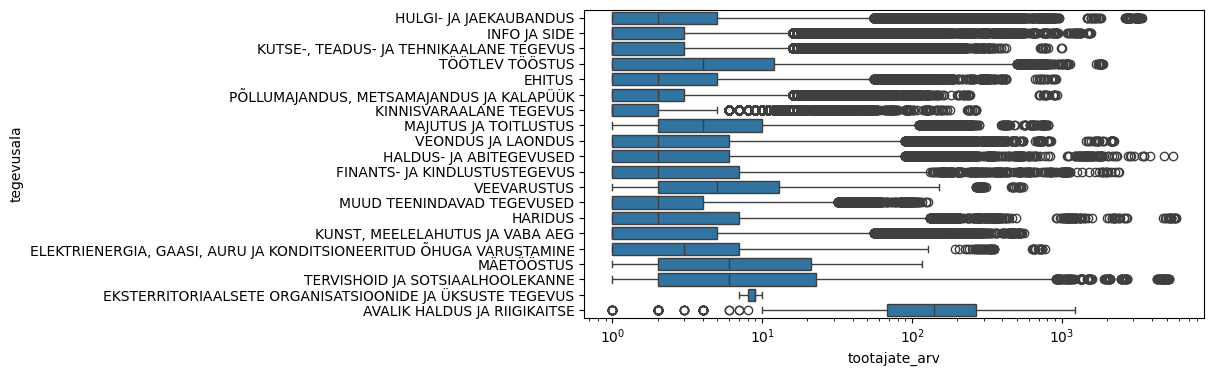

In [171]:
#ax =sns.boxplot(data=data, x="tootajate_arv", y="tegevusala", log_scale=10)
#ax.set_xscale ("log") # logaritmiline skaala, et näha ka väiksemaid väärtusi, kuna töötajate arv võib olla väga erinev.
# 
plt.figure(1, figsize=(8, 4))
sns.boxplot(data=data, x="tootajate_arv", y="tegevusala", log_scale=10)   

In [114]:
data.to_csv("emta_data.csv", index=False) # index=False tähendab, et ei salvestata ridade indekseid faili, kuna meil pole neid vaja.

## Töötaja ja käibe suhe

In [115]:
data

,registrikood,nimi,liik,maakond,kov,tegevusala,aasta,kvartal,riiklikud_maksud,toojoumaksud,kaive,tootajate_arv
0,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,1,1723565,1259900,34309154,254
1,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,2,2038192,1229742,30413704,243
2,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,3,2141341,1213643,23282177,244
3,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,4,1844403,1131417,21724706,240
4,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2026,1,1561762,1088007,19993085,236
...,...,...,...,...,...,...,...,...,...,...,...,...
943929,QQ000003,RAUMASTER OY,Mitteresident,NaN,NaN,HULGI- JA JAEKAUBANDUS,2023,4,22804,23491,47353,4
943930,QQ000003,RAUMASTER OY,Mitteresident,NaN,NaN,HULGI- JA JAEKAUBANDUS,2024,1,31928,33059,99940,4
943931,QQ000003,RAUMASTER OY,Mitteresident,NaN,NaN,HULGI- JA JAEKAUBANDUS,2024,2,25677,26511,5551,4
943932,QQ000003,RAUMASTER OY,Mitteresident,NaN,NaN,HULGI- JA JAEKAUBANDUS,2024,3,27572,28496,0,4


<Axes: xlabel='tootajate_arv', ylabel='kaive'>

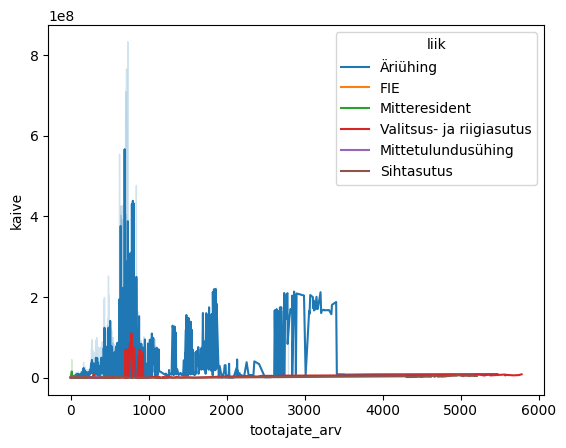

In [120]:
sns.lineplot(data=data, x="tootajate_arv", y="kaive", hue="liik")

<Axes: xlabel='tootajate_arv', ylabel='kaive'>

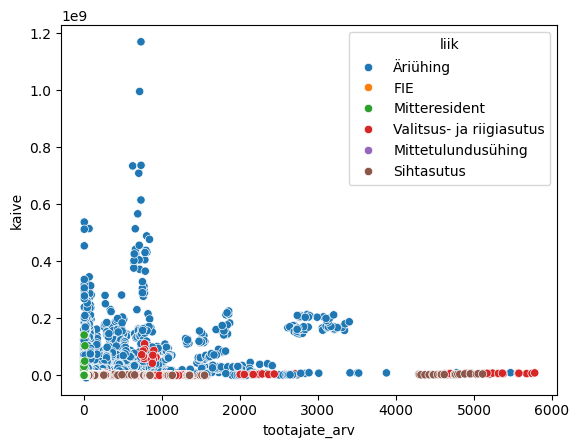

In [119]:
sns.scatterplot(data=data, x="tootajate_arv", y="kaive", hue="liik")

In [165]:
# -- any_value on funktsioon, mis võtab suvalise väärtuse grupi sees olevast veerust, 
# -- kuna me teame, et iga ettevõtte kohta on ainult üks liik, siis on see turvaline kasutada.
# alternatiiv oleks kasutada group by nimi, liik

# avg_revenue tabelis on iga ettevõtte keskmine ühe kuu käive, keskmine töötajate arv ja liik, 
# mis on järjestatud keskmise kuu käibe järgi kahanevalt ja piiratud 20 ettevõttega, 
# kellel on kõige suurem keskmine kuu käive.
avg_revenue = duckdb.sql("""
    SELECT 
           nimi, 
           round(avg(kaive)/3)::int as avg_kaive,
           round(avg(tootajate_arv))::int as tootajate_arv,
           any_value(liik) as liik,
            any_value(maakond) as maakond
        
    FROM data
    group by nimi
    ORDER BY avg_kaive DESC
    -- LIMIT 20
""").df()
avg_revenue

,nimi,avg_kaive,tootajate_arv,liik,maakond
0,EESTI ENERGIA AS,191064034,685,Äriühing,Harju
1,BOLT OPERATIONS OÜ,117072399,773,Äriühing,Harju
2,ORLEN EESTI OÜ,107338365,7,Äriühing,Harju
3,AS ELENGER GRUPP,85115652,80,Äriühing,Harju
4,TOYOTA BALTIC AS,73011311,43,Äriühing,Harju
...,...,...,...,...,...
80884,SMALLMIX OÜ,-5273,2,Äriühing,Harju
80885,KE KONSULT OÜ,-7337,2,Äriühing,Harju
80886,24/7 KAUBANDUS OÜ,-15756,4,Äriühing,Harju
80887,PROFI LOGISTIC OÜ,-15985,1,Äriühing,Harju


<Axes: xlabel='tootajate_arv', ylabel='avg_kaive'>

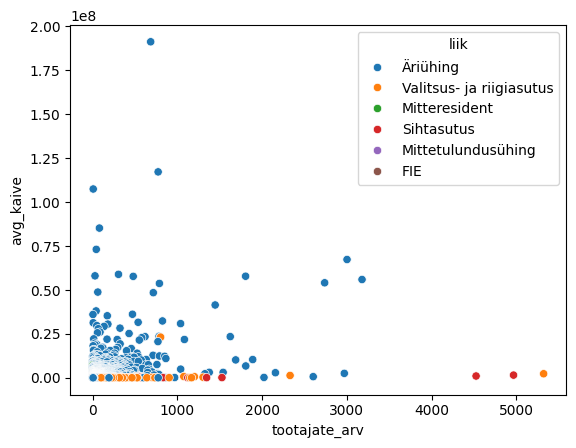

In [147]:
# graafikul on iga punkti kohta ettevõte, x-teljel on keskmine töötajate arv, y-teljel keskmine kuu käive ja punktide värv näitab ettevõtte liiki. 
# Graafik aitab visualiseerida, kas on seos töötajate arvu ja käibe vahel ning kas see seos erineb ettevõtete liikide lõikes.
sns.scatterplot(data=avg_revenue, x="tootajate_arv", y="avg_kaive", hue="liik")

<Axes: xlabel='tootajate_arv', ylabel='avg_kaive'>

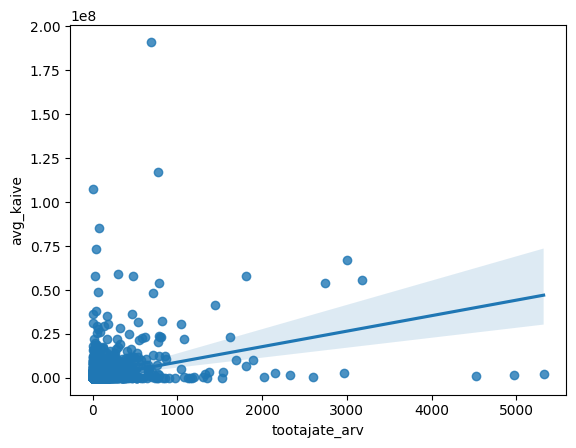

In [ ]:
# regressioonijoon, mis näitab üldist trendi, kuidas keskmine kuu käive muutub töötajate arvu kasvades.
sns.regplot(data=avg_revenue, x="tootajate_arv", y="avg_kaive")

In [152]:
#tahan näha, millised on tabeli veerud, et saaksin valida, mida graafikule panna
data.columns

Index(['registrikood', 'nimi', 'liik', 'maakond', 'kov', 'tegevusala', 'aasta',
       'kvartal', 'riiklikud_maksud', 'toojoumaksud', 'kaive',
       'tootajate_arv'],
      dtype='str')

<Axes: xlabel='tootajate_arv', ylabel='toojoumaksud'>

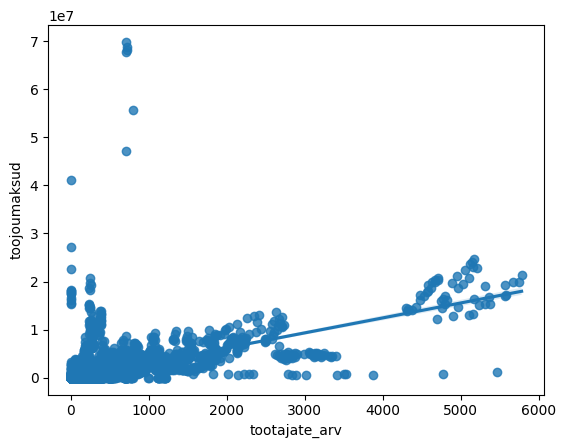

In [ ]:
#tahan näha, kas on seos töötajate arvu ja tööjõumaksud vahel, kas suurema töötajate arvuga ettevõtted maksavad rohkem tööjõumakse.
sns.regplot(data, x="tootajate_arv", y="toojoumaksud")

<Axes: xlabel='tootajate_arv', ylabel='toojoumaksud'>

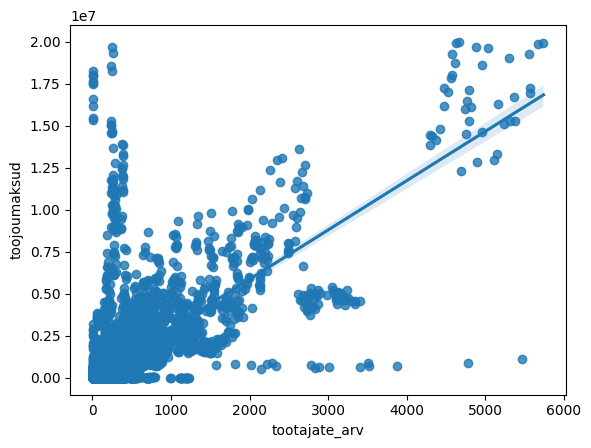

In [155]:
# Filtreerime välja need üksikud hiiglased, et näha tavalist seost
andmed_ilma_hiiglasteta = data[data['toojoumaksud'] < 20000000]

sns.regplot(data=andmed_ilma_hiiglasteta, x="tootajate_arv", y="toojoumaksud")


1. Üldine seos on olemas, aga see on "mürarikas"
Graafikul olev tõusev sirge näitab, et üldiselt on seos positiivne: mida rohkem on ettevõttes töötajaid, seda rohkem makstakse tööjõumakse. See on loogiline – rohkem päid tähendab rohkem palka ja rohkem makse.

2. "Anomaalsed hiiglased" (Need täpid seal üleval vasakul)
See on kõige huvitavam osa sinu graafikust! Sa näed gruppi täppe, kus töötajaid on vähe (alla 1000), aga maksud on hiiglaslikud (60–70 miljonit).

See viitab sellele, et nendes ettevõtetes on kas ülikõrged palgad või on tegemist raamatupidamisliku eripäraga (näiteks koondtasud või boonused, mis maksti välja vähestele inimestele).

Need punktid "tõmbavad" regressioonisirge ebaloomulikult järsuks.

3. "Alumise serva mass"
Graafiku allosas on näha väga tihe sinine ala. See näitab, et on väga palju ettevõtteid, kellel on tuhandeid töötajaid, aga kelle tööjõumaksud on võrreldes nende 70-miljoniliste hiiglastega märgatavalt madalamad. See tähendab, et töötajate arv üksi ei ennusta makse täpselt – määravaks on see, kui suurt palka neile makstakse.


"Jah, trend on tõusev, aga erandid on massiivsed. Meil on ettevõtteid, kes maksavad 700 töötajaga rohkem makse kui teised 5000 töötajaga."

In [162]:
# 1. Leiame need, kes on graafikul seal üleval vasakus nurgas
anomaaliad = duckdb.sql(f"""
    SELECT 
        nimi, 
        tegevusala, 
        tootajate_arv, 
        toojoumaksud,
        round(toojoumaksud / {TAX_PRECENTAGE} / NULLIF(tootajate_arv, 0) / 3, 0) AS arvutuslik_palk
    FROM data
    WHERE aasta = 2026 AND kvartal = 1
      AND tootajate_arv < 50         -- Vähe töötajaid
      AND arvutuslik_palk > 15000    -- Aga palk on "kosmoses"
    ORDER BY arvutuslik_palk DESC
""").df()

# 2. Kuva tulemus
anomaaliad

,nimi,tegevusala,tootajate_arv,toojoumaksud,arvutuslik_palk
0,AS PENSIONIKESKUS,FINANTS- JA KINDLUSTUSTEGEVUS,7,17677857,2490541.0
1,SIHTASUTUS TALLINNA HAMBAKLIINIK,TERVISHOID JA SOTSIAALHOOLEKANNE,1,682743,673317.0
2,GUARDTIME OÜ,INFO JA SIDE,1,128654,126878.0
3,RATASKAEVU HOSPITALITY OÜ,MAJUTUS JA TOITLUSTUS,6,694201,114103.0
4,PURILA TIMBER OÜ,TÖÖTLEV TÖÖSTUS,1,80081,78975.0
...,...,...,...,...,...
202,OUTFUNNEL OÜ,INFO JA SIDE,3,46277,15213.0
203,OÜ AVONA,EHITUS,1,15386,15174.0
204,"PONTOS BALTIC, AS",KINNISVARAALANE TEGEVUS,1,15359,15147.0
205,VIRAL ESTONIA OÜ,HALDUS- JA ABITEGEVUSED,1,15356,15144.0


2026. aasta I kvartali palgaandmete anomaaliad
Peamised leiud:

Andmete moonutused: Suurimad "palgad" (nt Pensionikeskus, SKA) on raamatupidamislik müra. Need asutused vahendavad riiklikke toetusi ja pensione, mis kajastuvad EMTA süsteemis ekslikult isiku tööjõukuluna.

Reaalsed tippsektorid: IT- ja tehnoloogiaettevõtted (nt Guardtime, Outfunnel) näitavad usutavat, kuid ekstreemset palgataset (15 000 – 26 000 €), mis peegeldab sektori kõrget lisandväärtust.

Registrivead: Teatud asutuste (nt SA Tallinna Hambakliinik) puhul ei kattu registris olev töötajate arv deklareeritud maksudega, tekitades ebatõeseid keskmisi.

Järeldus:
Statistilise keskmise arvutamisel tuleb finantsvahendus ja avalik haldus välistada, kuna need moonutavad Eesti tegelikku palgapilti. Puhastatud andmetes troonivad eesotsas IT-, energeetika- ja spetsialiseeritud konsultatsiooniettevõtted.

In [163]:
# Puhastatud päring
puhas_palk = duckdb.sql(f"""
    SELECT 
        nimi, 
        tegevusala, 
        tootajate_arv, 
        round(toojoumaksud / {TAX_PRECENTAGE} / NULLIF(tootajate_arv, 0) / 3, 0) AS kuu_keskmine_palk
    FROM data
    WHERE aasta = 2026 
      AND kvartal = 1 
      AND tootajate_arv > 5          -- Väldi päris pisikesi, kes pilti moonutavad
      AND kuu_keskmine_palk < 15000  -- Välista "kosmosemaksud" nagu Pensionikeskus
      AND tegevusala NOT IN ('AVALIK HALDUS JA RIIGIKAITSE', 'FINANTS- JA KINDLUSTUSTEGEVUS')
    ORDER BY kuu_keskmine_palk DESC
    LIMIT 20
""").df()

puhas_palk

,nimi,tegevusala,tootajate_arv,kuu_keskmine_palk
0,YBS INTERNATIONAL OÜ,HALDUS- JA ABITEGEVUSED,7,14883.0
1,OÜ QUALITISTA,INFO JA SIDE,70,14855.0
2,AVH GRUPP AS,"KUTSE-, TEADUS- JA TEHNIKAALANE TEGEVUS",8,14738.0
3,WHALAR ESTONIA OÜ,INFO JA SIDE,18,14715.0
4,OÜ MASI JEANS,TÖÖTLEV TÖÖSTUS,7,14463.0
5,NP CENTRAL OÜ,TÖÖTLEV TÖÖSTUS,14,14463.0
6,AKTSIASELTS EKSPRESS GRUPP,"KUTSE-, TEADUS- JA TEHNIKAALANE TEGEVUS",11,14443.0
7,INTERTRUST TECHNOLOGIES ESTONIA OÜ,INFO JA SIDE,6,14415.0
8,ORNYX OÜ,HULGI- JA JAEKAUBANDUS,10,14259.0
9,SIEMENS ENERGY OY EESTI FILIAAL,HULGI- JA JAEKAUBANDUS,28,14243.0


## Statistika

In [ ]:
# Mann-Whitney U test, et võrrelda Tartu ja Pärnu maakondade keskmisi käibesid, kuna andmed ei pruugi olla normaaljaotusega.
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(
    duckdb.sql("SELECT avg_kaive FROM avg_revenue WHERE maakond = 'Tartu' AND avg_kaive IS NOT NULL").df()["avg_kaive"],
    duckdb.sql("SELECT avg_kaive FROM avg_revenue WHERE maakond = 'Pärnu' AND avg_kaive IS NOT NULL").df()["avg_kaive"],
    alternative='two-sided'
)
float(p)
print(f"{p:.15f}")

#kuna tulemus on väga väike (< 0.05), siis võime järeldada, et Tartu ja Pärnu maakondade keskmised käibed erinevad statistiliselt oluliselt.

0.000000000058480
